In [1]:
# scikit-learn 의 캘리포니아 주택 가격에 대해 분석, 시각화, 전처리, 머신러닝, 튜닝까지 소스 만들어줘.

🚀 캘리포니아 주택 가격 분석 파이프라인 시작!
📊 데이터 형태: 20,640 행 × 9 열

📋 첫 5개 행:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

📊 기술 통계량:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386 

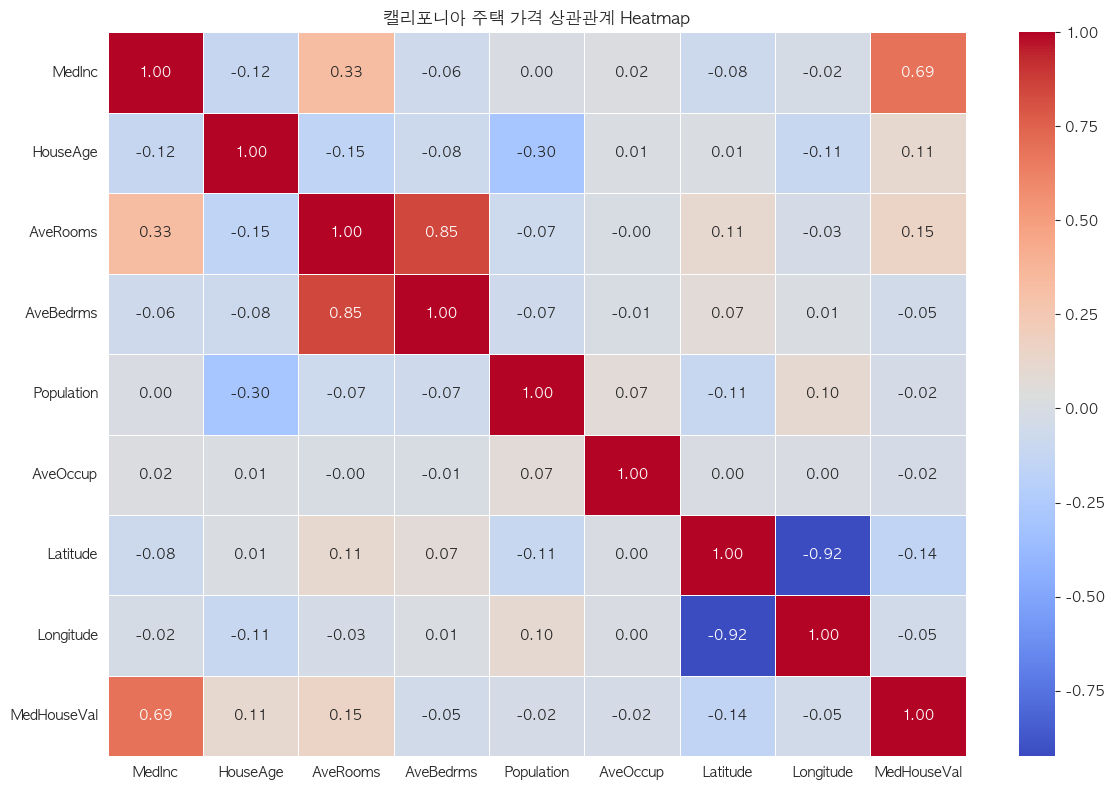

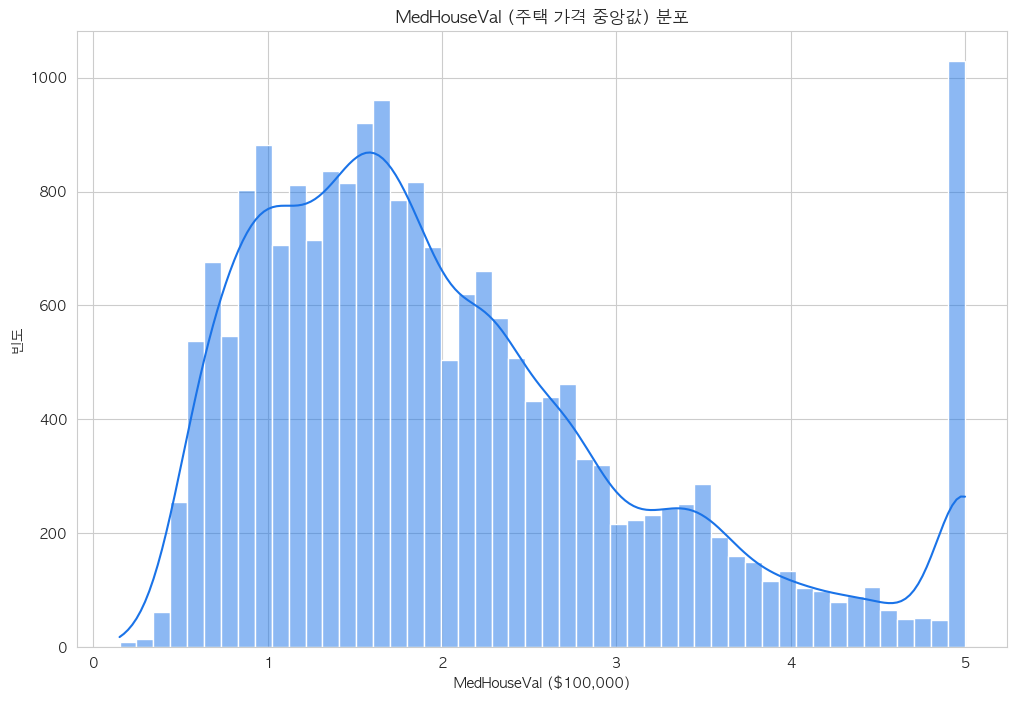

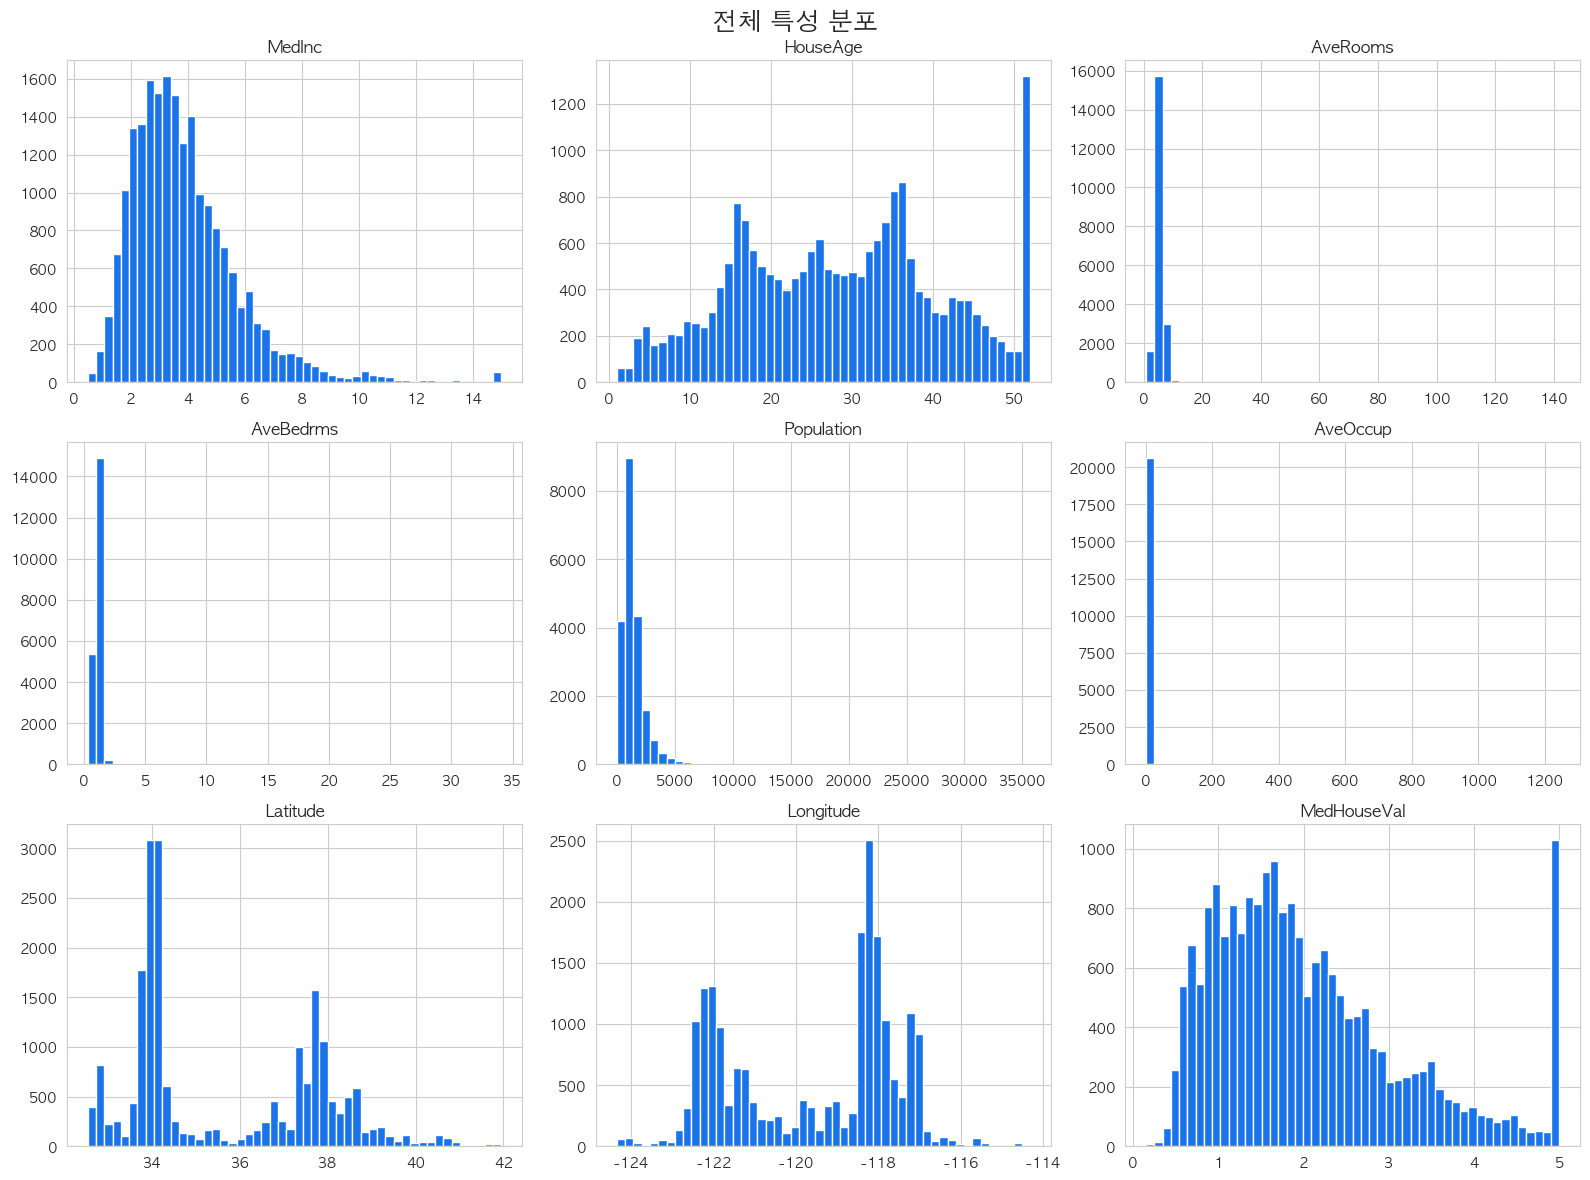

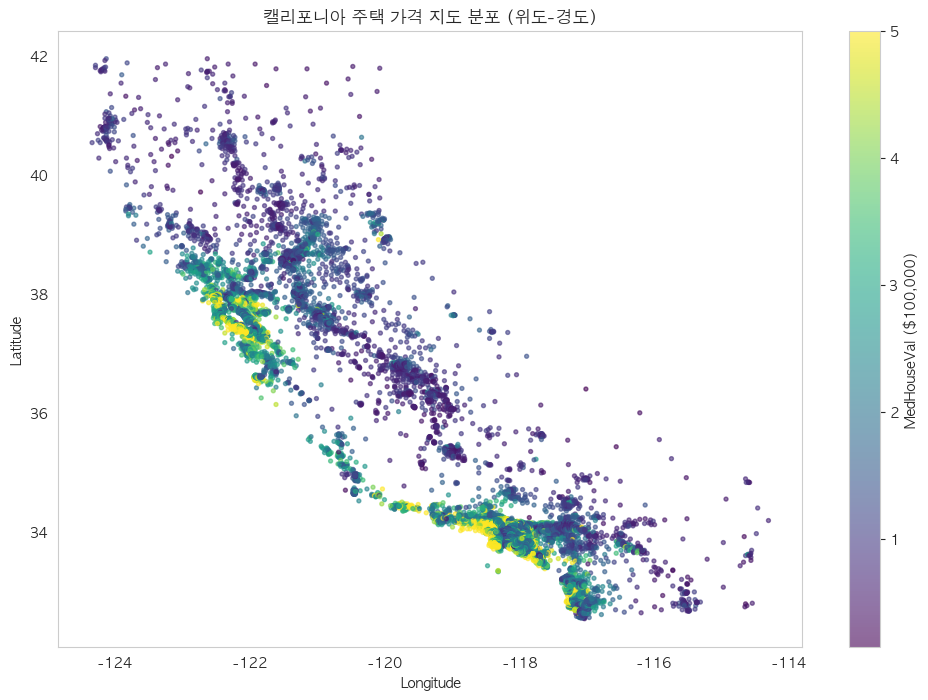

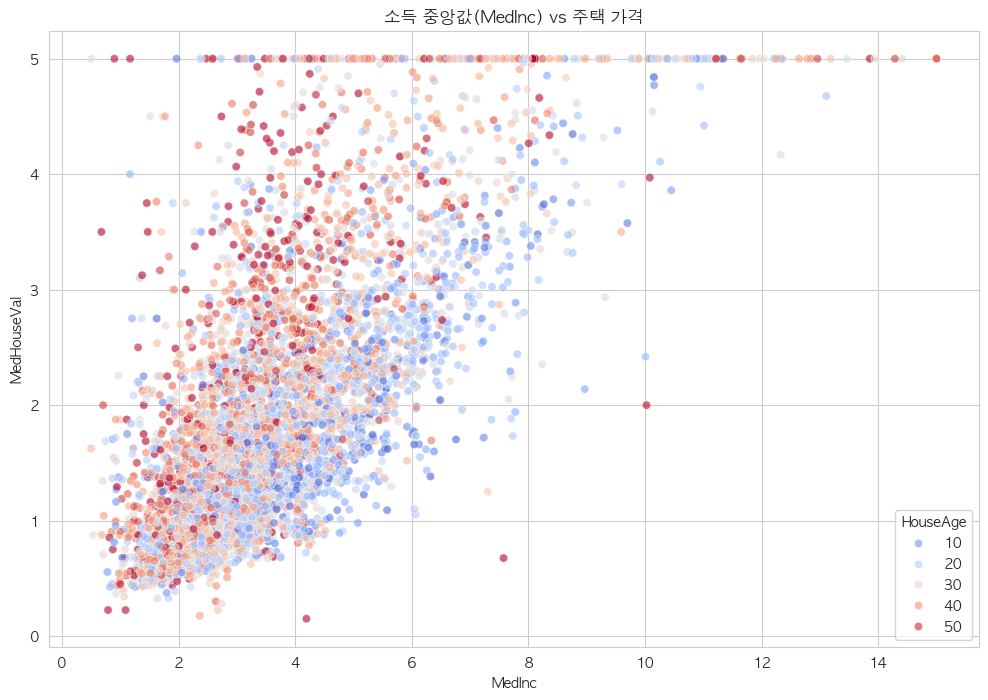

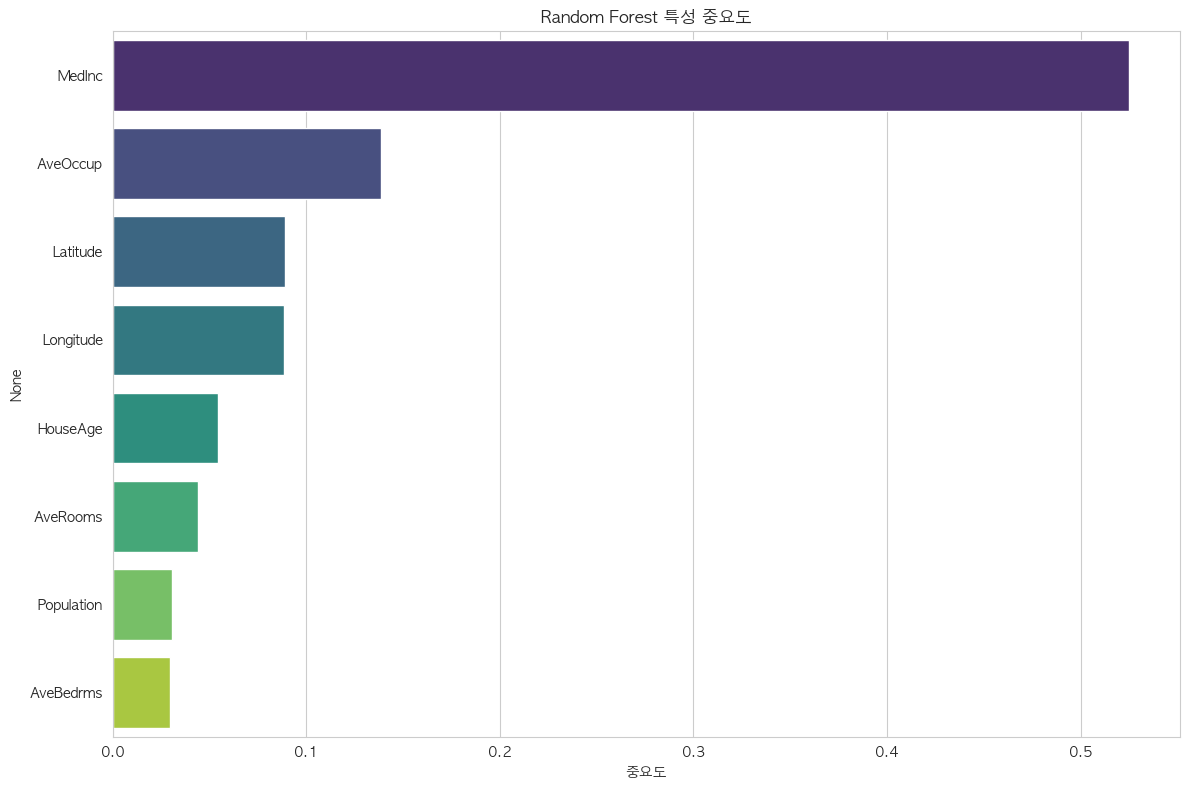

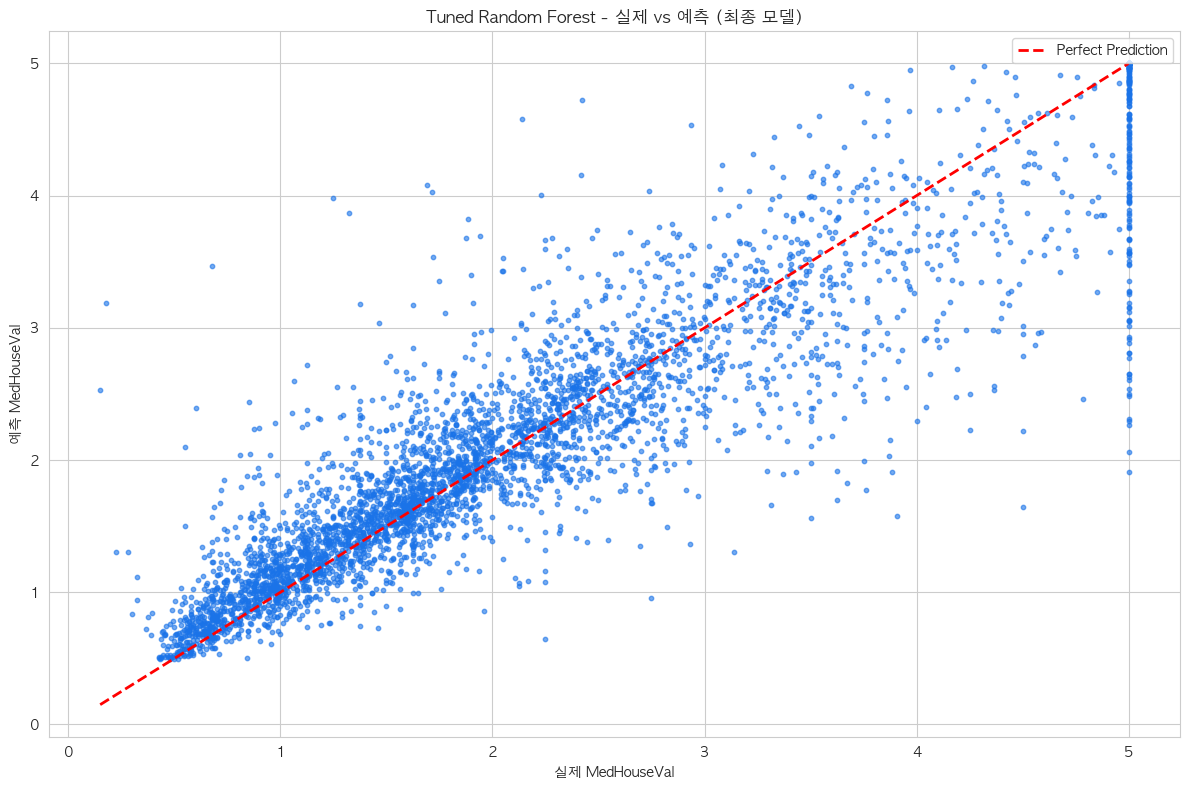

In [2]:
"""
캘리포니아 주택 가격 예측 완전 분석 파이프라인 (california_housing_analysis.py)
scikit-learn 내장 데이터셋 사용
- EDA + 시각화 + 전처리 + 머신러닝 + 하이퍼파라미터 튜닝
- 실행 방법: python california_housing_analysis.py
- 필요 라이브러리: pip install scikit-learn pandas matplotlib seaborn numpy
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# ==================== 설정 ====================
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
import platform
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("🚀 캘리포니아 주택 가격 분석 파이프라인 시작!")
print("=" * 60)
# ==================== 1. 데이터 로드 ====================
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target # 타겟: 주택 가격 중앙값 (단위: $100,000)
print(f"📊 데이터 형태: {df.shape[0]:,} 행 × {df.shape[1]} 열")
print("\n📋 첫 5개 행:")
print(df.head())
print("\n📊 기술 통계량:")
print(df.describe().round(3))
# ==================== 2. 탐색적 데이터 분석 (EDA) ====================
print("\n🔥 MedHouseVal와의 상관관계 (내림차순):")
corr = df.corr()
print(corr['MedHouseVal'].sort_values(ascending=False).round(3))
# ==================== 3. 시각화 ====================
print("\n📈 시각화 진행 중...")
# 3-1. 상관관계 히트맵
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('캘리포니아 주택 가격 상관관계 Heatmap')
plt.tight_layout()
# ==================== 3-2. 타겟 변수 분포 ====================
plt.figure()
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='#1a73e8')
plt.title('MedHouseVal (주택 가격 중앙값) 분포')
plt.xlabel('MedHouseVal ($100,000)')
plt.ylabel('빈도')
# ==================== 3-3. 전체 특성 히스토그램 ====================
df.hist(bins=50, figsize=(16, 12), color='#1a73e8')
plt.suptitle('전체 특성 분포', fontsize=18)
plt.tight_layout()
# ==================== 3-4. 위치 기반 가격 분포 (지도-like) ====================
plt.figure()
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                     c=df['MedHouseVal'], cmap='viridis', alpha=0.6, s=8)
plt.colorbar(scatter, label='MedHouseVal ($100,000)')
plt.title('캘리포니아 주택 가격 지도 분포 (위도-경도)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
# ==================== 3-5. 가장 중요한 특성 산점도 ====================
plt.figure()
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df.sample(5000, random_state=42),
                alpha=0.6, hue='HouseAge', palette='coolwarm')
plt.title('소득 중앙값(MedInc) vs 주택 가격')
print("✅ 시각화 완료!")
# ==================== 4. 데이터 전처리 ====================
print("\n🔧 데이터 전처리 시작...")
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
# Train/Test 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"훈련 데이터: {X_train.shape[0]:,}개")
print(f"테스트 데이터: {X_test.shape[0]:,}개")
# 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ 전처리 완료 (스케일링 + 데이터 분리)")
# ==================== 5. 머신러닝 모델 학습 ====================
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n🔥 {model_name} 성능")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² : {r2:.4f}")
    return r2
# 모델 1: Linear Regression (기준 모델)
print("\n📌 Linear Regression 학습 중...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model(y_test, y_pred_lr, "Linear Regression")
# 모델 2: Random Forest Regressor
print("\n📌 Random Forest 학습 중...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model(y_test, y_pred_rf, "Random Forest")
# 특성 중요도 시각화
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure()
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest 특성 중요도')
plt.xlabel('중요도')
plt.tight_layout()
# ==================== 6. 하이퍼파라미터 튜닝 (GridSearchCV) ====================
print("\n🔧 GridSearchCV 하이퍼파라미터 튜닝 시작... (약 1~3분 소요)")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)
print(f"✅ 최적 파라미터: {grid_search.best_params_}")
print(f"✅ 최고 CV RMSE: {-grid_search.best_score_:.4f}")
# 최적 모델로 최종 평가
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
evaluate_model(y_test, y_pred_best, "Tuned Random Forest")
# Cross Validation 최종 검증
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n📈 5-Fold CV R² 평균: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
# ==================== 7. 최종 결과 시각화 ====================
plt.figure()
plt.scatter(y_test, y_pred_best, alpha=0.6, color='#1a73e8', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('실제 MedHouseVal')
plt.ylabel('예측 MedHouseVal')
plt.title('Tuned Random Forest - 실제 vs 예측 (최종 모델)')
plt.legend()
plt.tight_layout()
print("\n" + "=" * 60)
print("🎉 모든 분석 완료!")
print("\n✅ 분석이 끝났습니다!")

In [3]:
# end